In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("NovaMart_Sales.csv")

In [3]:
print("="*80)
print("SALES AND PERFORMANCE METRICS ANALYSIS")
print("="*80)

SALES AND PERFORMANCE METRICS ANALYSIS


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 48 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_id                 2000 non-null   object 
 1   order_date               2000 non-null   object 
 2   ship_date                2000 non-null   object 
 3   year                     2000 non-null   int64  
 4   month                    2000 non-null   object 
 5   quarter                  2000 non-null   int64  
 6   week                     2000 non-null   int64  
 7   season                   2000 non-null   object 
 8   customer_id              2000 non-null   object 
 9   customer_type            2000 non-null   object 
 10  customer_age_group       2000 non-null   object 
 11  customer_gender          2000 non-null   object 
 12  loyalty_status           2000 non-null   object 
 13  customer_lifetime_value  2000 non-null   int64  
 14  product_id              

## 1

## Monthly sales by year


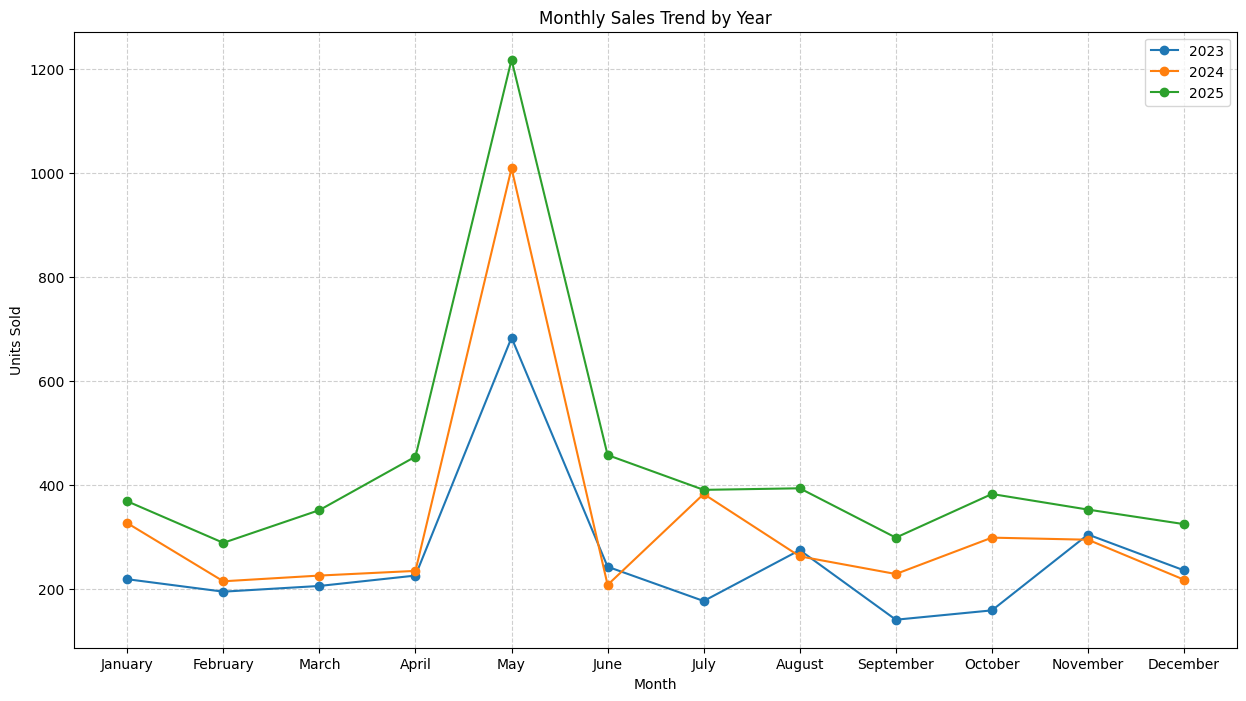

In [5]:
# 1. Update categories to match the full names in the dataset
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_sales = (
    df.groupby(['year', 'month'])['quantity']
    .sum()
    .reset_index()
)

# 2. Re-apply categorical logic
monthly_sales['month'] = pd.Categorical(
    monthly_sales['month'], 
    categories=month_order, 
    ordered=True
)

# 3. Sort and Drop any potential NaNs (from mismatched labels)
monthly_sales = monthly_sales.sort_values(['year', 'month']).dropna(subset=['month'])

# Now the plot will render perfectly
plt.figure(figsize=(15,8))

for year in monthly_sales['year'].unique():
    data = monthly_sales[monthly_sales['year'] == year]
    # Convert month to string explicitly during plotting to keep Matplotlib happy
    plt.plot(data['month'].astype(str), data['quantity'], marker='o', label=year)

plt.title('Monthly Sales Trend by Year')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.grid(True, linestyle='--', alpha=0.6) # Added grid for better readability
plt.legend()
plt.show()

## 2

## Sales Vs Profit


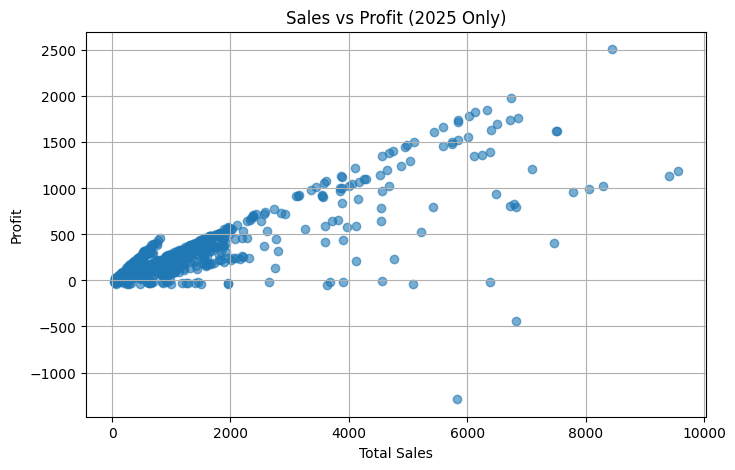

In [6]:
# Filter for 2025
df_2025 = df[df['year'] == 2025]

plt.figure(figsize=(8,5))
plt.scatter(df_2025['total_sales'], df_2025['profit'], alpha=0.6)

plt.title("Sales vs Profit (2025 Only)")
plt.xlabel("Total Sales")
plt.ylabel("Profit")
plt.grid(True)
plt.show()


## 3 .Profit wise Product Category

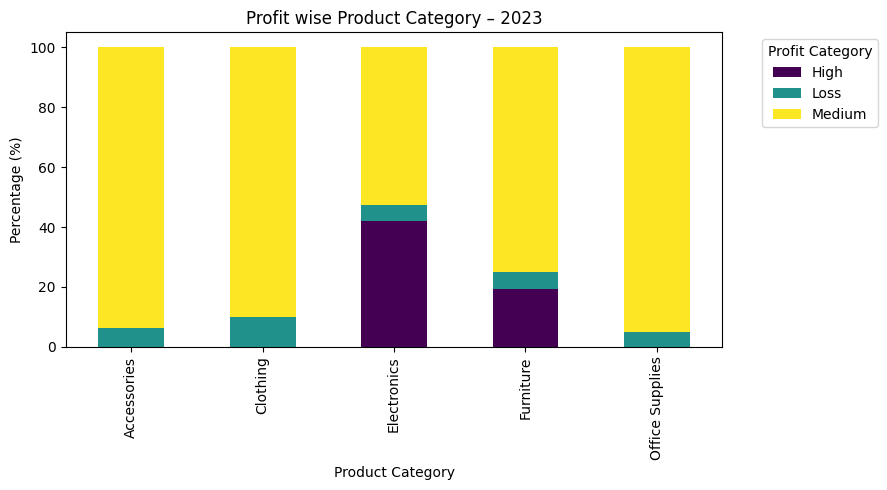

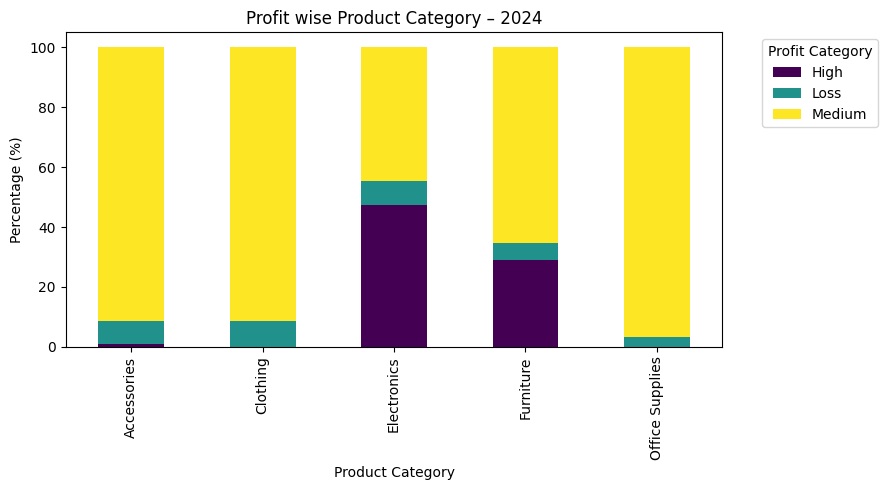

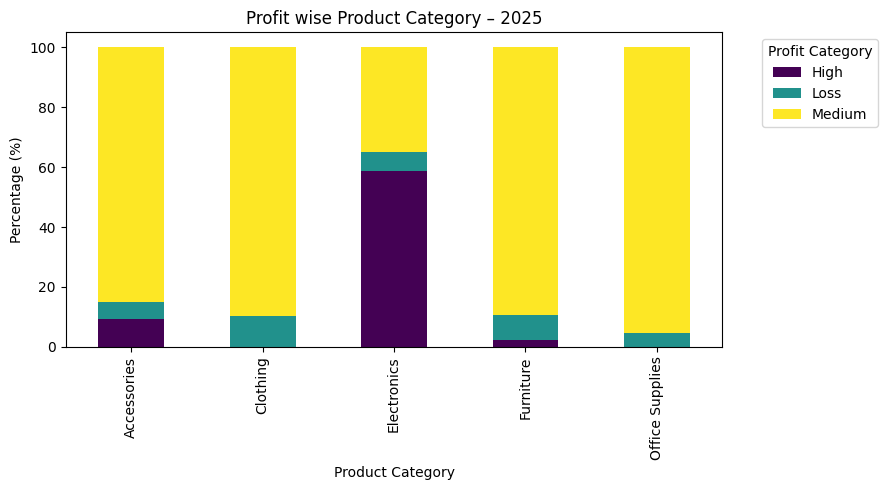

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

profit_df = df.dropna(subset=['profit_category'])

cat_yoy = pd.crosstab(
    [profit_df['year'], profit_df['category']],
    profit_df['profit_category']
)

# Convert to percentage
cat_yoy_pct = cat_yoy.div(cat_yoy.sum(axis=1), axis=0) * 100

# Plot for each year
for year in cat_yoy_pct.index.get_level_values(0).unique():
    cat_yoy_pct.loc[year].plot(
        kind='bar',
        stacked=True,
        figsize=(9,5),
        cmap = "viridis"
    )
    plt.title(f"Profit wise Product Category – {year}")
    plt.xlabel("Product Category")
    plt.ylabel("Percentage (%)")
    plt.legend(title="Profit Category", bbox_to_anchor=(1.05,1))
    plt.tight_layout()
    plt.show()


## 4

## Revenue Composition by Category

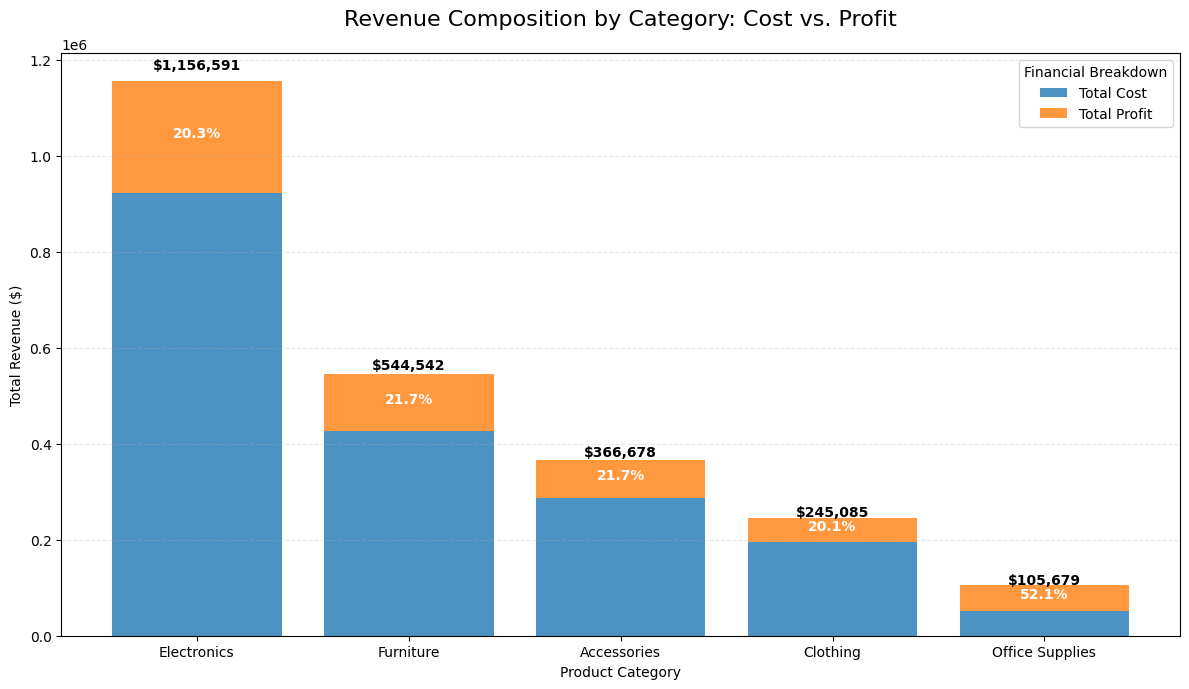

In [8]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# 1. Prepare the data: Calculate total Cost and total Profit per category
category_breakdown = df.groupby('category').agg(
    total_cost=('cost_price', lambda x: (x * df.loc[x.index, 'quantity']).sum()),
    total_profit=('profit', 'sum')
).sort_values('total_cost', ascending=False)

# 2. Create the Stacked Plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot Costs
ax.bar(
    category_breakdown.index,
    category_breakdown['total_cost'],
    label='Total Cost',
    alpha=0.8
)

# Plot Profit on top of Costs
ax.bar(
    category_breakdown.index,
    category_breakdown['total_profit'],
    bottom=category_breakdown['total_cost'],
    label='Total Profit',
    alpha=0.8
)

# 3. Add Value Labels
for i, (cost, profit) in enumerate(
    zip(category_breakdown['total_cost'], category_breakdown['total_profit'])
):
    total = cost + profit
    margin_pct = (profit / total) * 100

    # Total Revenue label
    ax.text(
        i,
        total + (total * 0.02),
        f'${total:,.0f}',
        ha='center',
        fontweight='bold'
    )

    # Profit Margin %
    ax.text(
        i,
        cost + (profit / 2),
        f'{margin_pct:.1f}%',
        ha='center',
        color='white',
        fontweight='bold'
    )

# 4. Formatting (REMOVE EXPONENT HERE)
ax.set_title("Revenue Composition by Category: Cost vs. Profit", fontsize=16, pad=20)
ax.set_xlabel("Product Category")
ax.set_ylabel("Total Revenue ($)")

# Disable scientific notation
ax.ticklabel_format(style='plain', axis='y')
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

ax.legend(title="Financial Breakdown")
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## 5

## Average Profit Margin by Product Category

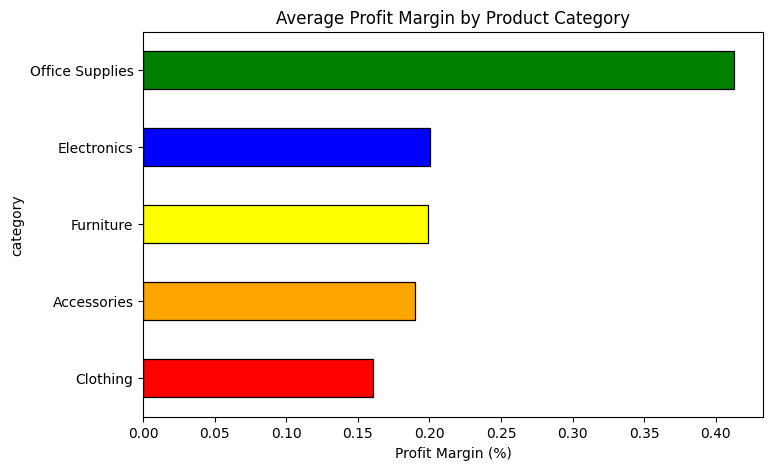

In [9]:
category_profit = df.groupby('category')['profit_margin'].mean().sort_values()
colors = ['red','orange','yellow','blue','green']
category_profit.plot(kind='barh', figsize=(8,5) ,edgecolor="black",linewidth=0.9 ,color = colors)
plt.title("Average Profit Margin by Product Category")
plt.xlabel("Profit Margin (%)")
plt.show()

## 6 .TOP 5 Brand

In [10]:
product_perf = df.groupby(
    ['product_name', 'category', 'brand']
).agg(
    total_sales=('total_sales', 'sum'),
    total_profit=('profit', 'sum')
).reset_index()

# Create performance score
product_perf['performance_score'] = (
    product_perf['total_sales'].rank(pct=True) +
    product_perf['total_profit'].rank(pct=True)
)

# Top 10 products
top_products = product_perf.sort_values(
    by='performance_score', ascending=False
).head(10)

top_products[['product_name','category','brand','total_sales','total_profit']]
product_perf['performance_score'] = (
    product_perf['total_sales'].rank(pct=True) +
    product_perf['total_profit'].rank(pct=True)
)

top_products = product_perf.sort_values(
    by='performance_score', ascending=False
).head(10)

top_products[['product_name','category','brand','total_sales','total_profit']]

,product_name,category,brand,total_sales,total_profit
153,Nike Smartphones,Electronics,Nike,70605.41,13851.87
77,HP Tablets,Electronics,HP,44410.29,9577.50
97,IKEA Tablets,Electronics,IKEA,41771.81,9551.24
127,Logitech Laptops,Electronics,Logitech,40638.09,8863.25
13,Adidas Smartphones,Electronics,Adidas,38370.03,8549.36
117,Levis Tablets,Electronics,Levis,39965.38,8092.15
113,Levis Smartphones,Electronics,Levis,41331.56,6954.55
177,Samsung Tablets,Electronics,Samsung,32395.56,8786.59
73,HP Smartphones,Electronics,HP,38139.87,8026.71
173,Samsung Smartphones,Electronics,Samsung,32455.18,8357.70


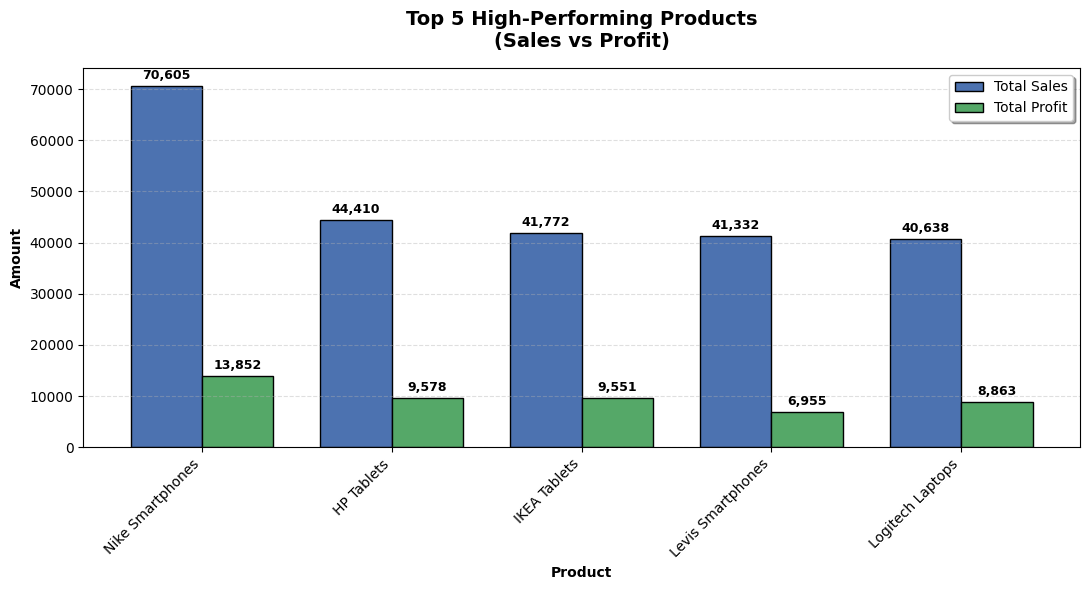

In [11]:

import matplotlib.pyplot as plt

# Top 5 products by total sales
top5_products = top_products.sort_values(
    by='total_sales', ascending=False
).head(5)

# Plot
ax = top5_products.set_index('product_name')[['total_sales', 'total_profit']].plot(
    kind='bar',
    figsize=(11, 6),
    width=0.75,
    color=['#4C72B0', '#55A868'],   # Sales (blue), Profit (green)
    edgecolor='black',
    linewidth=1
)

# Title & labels
plt.title(
    "Top 5 High-Performing Products\n(Sales vs Profit)",
    fontsize=14,
    fontweight='bold',
    pad=15
)
plt.ylabel("Amount", fontweight='bold')
plt.xlabel("Product", fontweight='bold')

# Rotate x labels
plt.xticks(rotation=45, ha='right')

# Grid
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.0f}',
        padding=3,
        fontweight='bold',
        fontsize=9
    )

# Legend
plt.legend(
    ['Total Sales', 'Total Profit'],
    frameon=True,
    shadow=True
)

plt.tight_layout()
plt.show()


## 7 .Top 2 Brand By category

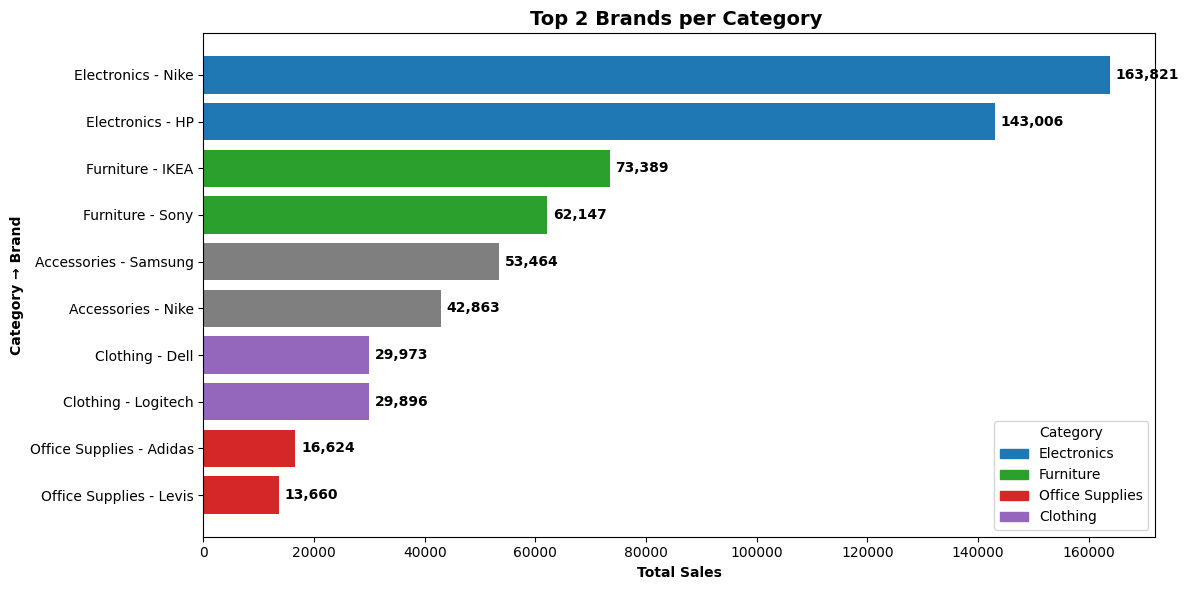

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ===============================
# 1. Create pivot table
# ===============================
brand_cat = pd.pivot_table(
    df,
    index='brand',
    columns='category',
    values='total_sales',
    aggfunc='sum'
)

# ===============================
# 2. Order categories by total sales (high → low)
# ===============================
category_order = brand_cat.sum().sort_values(ascending=False).index

# ===============================
# 3. Build dataframe: top 2 brands per category
# ===============================
rows = []

for category in category_order:
    top2 = brand_cat[category].nlargest(2)
    for brand, sales in top2.items():
        rows.append({
            'Category': category,
            'Brand': brand,
            'Total Sales': sales
        })

top2_df = pd.DataFrame(rows)

# ===============================
# 4. Sort globally by sales (descending)
# ===============================
top2_df = top2_df.sort_values('Total Sales', ascending=False)

# ===============================
# 5. Assign colors to categories (with fallback)
# ===============================
category_colors = {
    'Electronics': '#1f77b4',
    'Furniture': '#2ca02c',
    'Office Supplies': '#d62728',
    'Clothing': '#9467bd'
}

# Map colors safely (no NaN → no crash)
colors = top2_df['Category'].map(category_colors).fillna('#7f7f7f')

# ===============================
# 6. Plot horizontal bar chart
# ===============================
plt.figure(figsize=(12, 6))

bars = plt.barh(
    top2_df['Category'] + " - " + top2_df['Brand'],
    top2_df['Total Sales'],
    color=colors
)

plt.gca().invert_yaxis()

plt.title("Top 2 Brands per Category ", fontsize=14, fontweight='bold')
plt.xlabel("Total Sales", fontweight='bold')
plt.ylabel("Category → Brand", fontweight='bold')

# ===============================
# 7. Add value labels
# ===============================
plt.bar_label(bars, fmt='{:,.0f}', padding=4, fontweight='bold')

# ===============================
# 8. Custom legend
# ===============================
legend_handles = [
    Patch(color=color, label=cat)
    for cat, color in category_colors.items()
]
plt.legend(handles=legend_handles, title="Category")

plt.tight_layout()
plt.show()

## 8. Discount impact on sales & profit

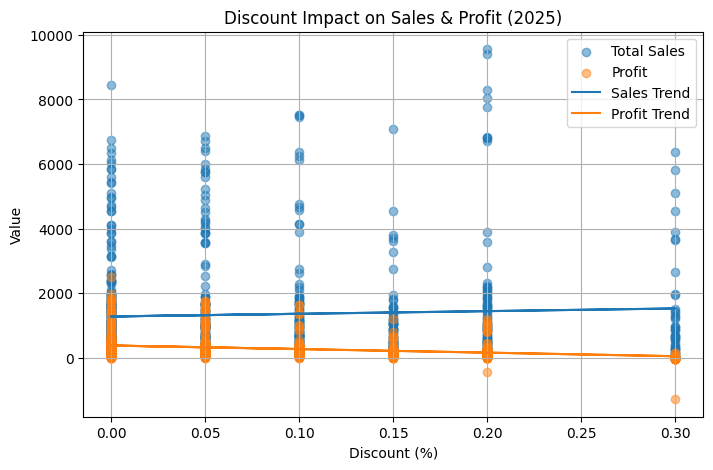

In [13]:
import numpy as np

df_2025 = df[df['year'] == 2025]

# Trend lines
sales_fit = np.polyfit(df_2025['discount'], df_2025['total_sales'], 1)
profit_fit = np.polyfit(df_2025['discount'], df_2025['profit'], 1)

plt.figure(figsize=(8,5))
plt.scatter(df_2025['discount'], df_2025['total_sales'], alpha=0.5, label='Total Sales')
plt.scatter(df_2025['discount'], df_2025['profit'], alpha=0.5, label='Profit')

plt.plot(df_2025['discount'], sales_fit[0]*df_2025['discount'] + sales_fit[1], label='Sales Trend')
plt.plot(df_2025['discount'], profit_fit[0]*df_2025['discount'] + profit_fit[1], label='Profit Trend')

plt.xlabel("Discount (%)")
plt.ylabel("Value")
plt.title("Discount Impact on Sales & Profit (2025)")
plt.legend()
plt.grid(True)
plt.show()


## 9.Customer type

                total_revenue  total_profit
customer_type                              
Corporate           877998.32     197110.82
Individual          819550.53     175969.76
Small Business      775856.38     164552.94


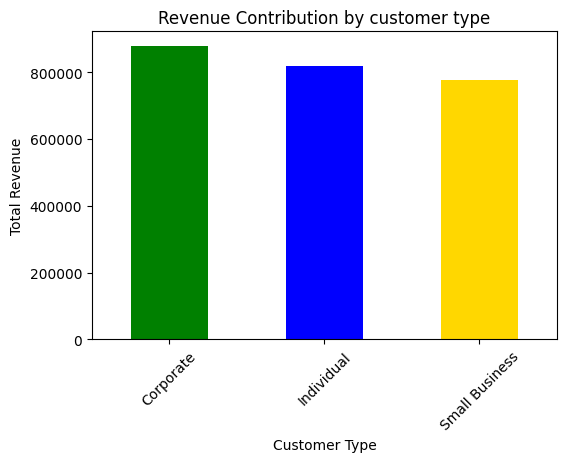

In [14]:
cust_contribution = df.groupby('customer_type').agg(
    total_revenue=('total_sales', 'sum'),
    total_profit=('profit', 'sum')
)
print(cust_contribution)

colors =['green', 'blue','gold']
cust_contribution['total_revenue'].plot(kind='bar', figsize=(6,4), color = colors)
plt.title("Revenue Contribution by customer type")
plt.xticks(rotation = 45)
plt.xlabel("Customer Type")
plt.ylabel("Total Revenue")
plt.show()

## 10. customer Loyalty status impact on profit and sales

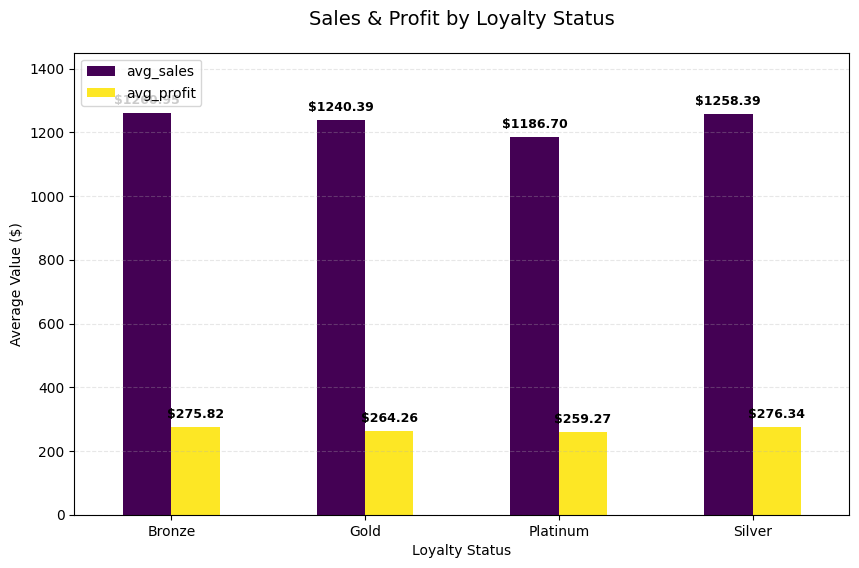

In [15]:
# Aggregate data
loyalty = df.groupby('loyalty_status').agg(
    avg_sales=('total_sales', 'mean'),
    avg_profit=('profit', 'mean')
)

# Plot
ax = loyalty.plot(kind='bar', figsize=(10, 6), cmap='viridis')

# Add value labels
for p in ax.patches:
    ax.annotate(f'${p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=9,
                fontweight='bold')

plt.title("Sales & Profit by Loyalty Status", fontsize=14, pad=20)
plt.ylabel("Average Value ($)")
plt.xlabel("Loyalty Status")
plt.xticks(rotation=0)
plt.ylim(0, loyalty['avg_sales'].max() * 1.15) # Add space for labels
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## 11.customer rating

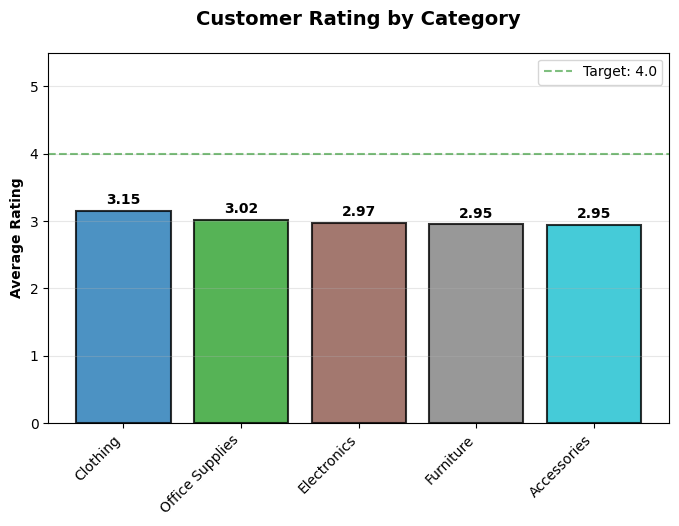

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare the data correctly
category_metrics = df.groupby('category').agg(
    Avg_Rating=('customer_rating', 'mean')
).sort_values('Avg_Rating', ascending=False)

# 2. Generate color palette
colors = plt.cm.tab10(np.linspace(0, 1, len(category_metrics)))

plt.figure(figsize=(20, 14))
ax3 = plt.subplot(3, 3, 3)

# 3. Plot using the now-existent 'Avg_Rating'
ax3.bar(category_metrics.index, category_metrics['Avg_Rating'], 
        color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Adding value labels (like we did for loyalty) for extra polish
for i, val in enumerate(category_metrics['Avg_Rating']):
    ax3.text(i, val + 0.1, f'{val:.2f}', ha='center', fontweight='bold')

ax3.set_ylabel('Average Rating', fontweight='bold')
ax3.set_title('Customer Rating by Category', fontsize=14, fontweight='bold', pad=20)
ax3.set_ylim([0, 5.5]) # Slightly higher to fit labels

ax3.set_xticks(range(len(category_metrics.index)))
ax3.set_xticklabels(category_metrics.index, rotation=45, ha='right')

ax3.axhline(y=4.0, color='green', linestyle='--', alpha=0.5, label='Target: 4.0')
ax3.grid(axis='y', alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

## 12.Regional sales distribution

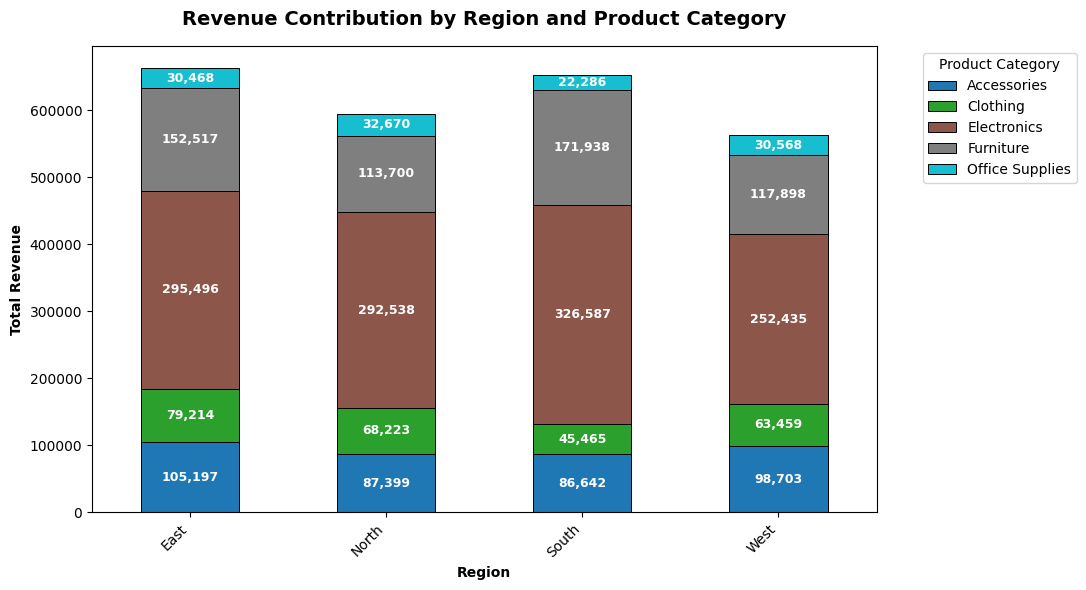

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Pivot table
pivot_1 = pd.pivot_table(
    df,
    index='region',
    columns='category',
    values='total_sales',
    aggfunc='sum'
)

# Plot stacked bar chart
ax = pivot_1.plot(
    kind='bar',
    stacked=True,
    figsize=(11, 6),
    cmap='tab10',
    edgecolor='black',
    linewidth=0.7
)

# Titles & labels
plt.title(
    "Revenue Contribution by Region and Product Category",
    fontsize=14,
    fontweight='bold',
    pad=15
)
plt.xlabel("Region", fontweight='bold')
plt.ylabel("Total Revenue", fontweight='bold')

plt.xticks(rotation=45, ha='right')

# Legend
plt.legend(
    title="Product Category",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# ============================
# Add value labels to stacks
# ============================
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                f'{height:,.0f}',
                ha='center',
                va='center',
                fontsize=9,
                fontweight='bold',
                color='white'
            )

plt.tight_layout()
plt.show()


## 13. Sales by Channel

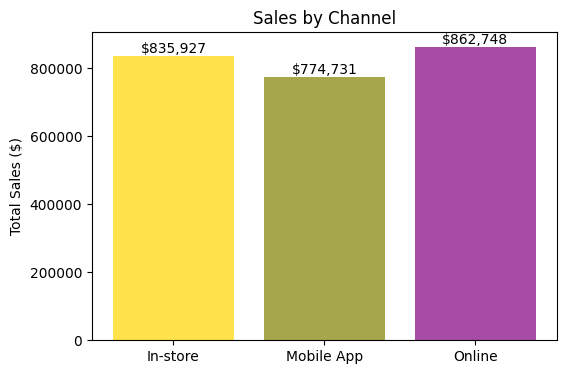

In [18]:
channel_performance = df.groupby('sales_channel').agg({
    'total_sales': 'sum',
    'profit': 'sum',
    'order_id': 'count',
    'profit_margin': 'mean'
}).round(2)
colors =["gold",'olive','purple']
plt.figure(figsize=(6,4))
plt.bar(
    channel_performance.index,
    channel_performance['total_sales'],
    alpha=0.7 , color = colors
)

for i, v in enumerate(channel_performance['total_sales']):
    plt.text(i, v, f'${v:,.0f}', ha='center', va='bottom')

plt.ylabel('Total Sales ($)')
plt.title('Sales by Channel')
plt.show()

## 14.Return on investment

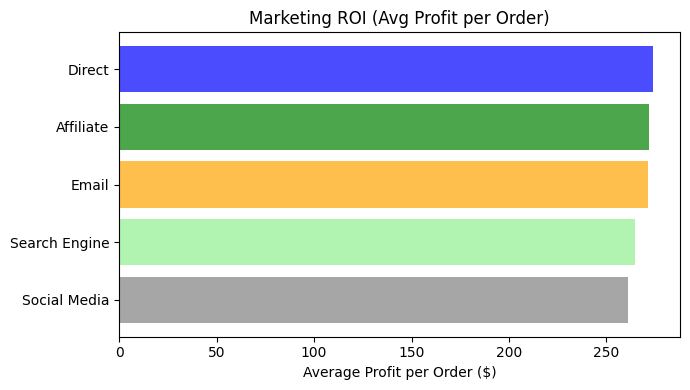

In [19]:
marketing_sales = df.groupby('marketing_source').agg(
    profit=('profit', 'sum'),
    order_count=('order_id', 'nunique')
)
marketing_sales['ROI'] = (
    marketing_sales['profit'] / marketing_sales['order_count']
)
marketing_sales_sorted = marketing_sales.sort_values('ROI', ascending=False)

plt.figure(figsize=(7,4))
colors =["blue",'green','orange','lightgreen','grey','yellow','pink']
plt.barh(
    marketing_sales_sorted.index,
    marketing_sales_sorted['ROI'],
    alpha=0.7 , color = colors
)

plt.xlabel('Average Profit per Order ($)')
plt.title('Marketing ROI (Avg Profit per Order)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 15. Payment method

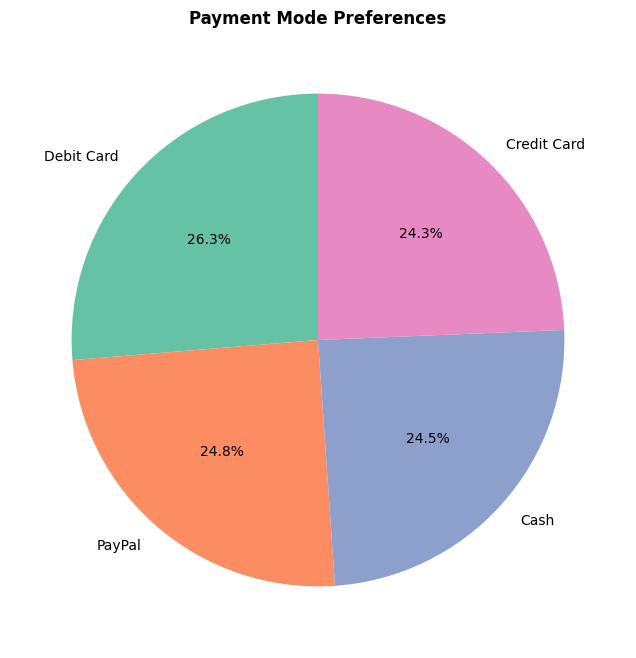

In [20]:
# Payment mode preferences
payment_mode_dist = df.groupby('payment_mode').agg({
    'order_id': 'count',
    'total_sales': 'sum'
})

payment_mode_dist['percentage'] = (
    payment_mode_dist['order_id'] /
    payment_mode_dist['order_id'].sum() * 100
).round(1)

payment_mode_dist = payment_mode_dist.sort_values('order_id', ascending=False)

# Colors
colors_payment = plt.cm.Set2(range(len(payment_mode_dist)))

# Plot pie chart
plt.figure(figsize = (12,8))
plt.pie(
    payment_mode_dist['order_id'].values,
    labels=payment_mode_dist.index,
    autopct='%1.1f%%',
    colors=colors_payment,
    startangle=90
)

plt.title('Payment Mode Preferences', fontsize=12, fontweight='bold')
plt.show()


## 16. Top Salesperson performance

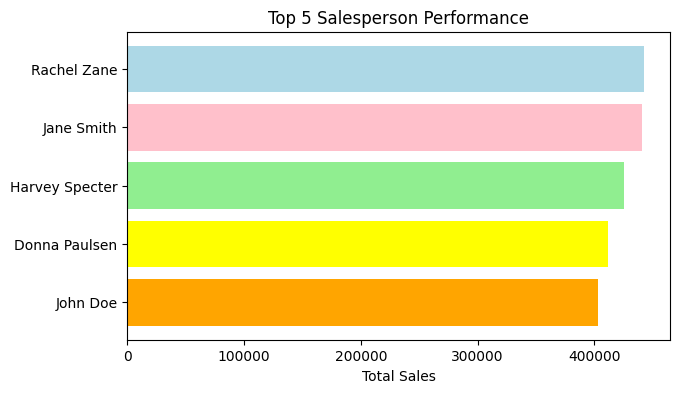

In [21]:
salesperson_perf = df.groupby('sales_person').agg({
    'total_sales': 'sum',
    'order_id': 'count'
}).sort_values('total_sales', ascending=False).head(5)

plt.figure(figsize=(7,4))
colors =['lightblue', 'pink','lightgreen','yellow','orange']
plt.barh(
    salesperson_perf.index,
    salesperson_perf['total_sales'], color = colors
)

plt.xlabel('Total Sales')
plt.title('Top 5 Salesperson Performance')
plt.gca().invert_yaxis()
plt.show()